In [1]:
import pandas as pd


## Load dataset

In [2]:
url = "https://raw.githubusercontent.com/iPriyadarshi/MachineLearning-BCS4706/main/dataset/insurance.csv"
df = pd.read_csv(url)


## Understanding the data

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [4]:
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.columns


Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

## Preprocessing

In [6]:
# convert categorical columns to numeric

df = pd.get_dummies(df, drop_first=True)

print("Columns after encoding:")
print(df.columns)


Columns after encoding:
Index(['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='str')


In [7]:
df.head()


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


## Feature Selection

In [8]:
X = df.drop('charges',axis=1)
y = df['charges']


In [9]:
X.head()


,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,False,True,False,False,True
1,18,33.770,1,True,False,False,True,False
2,28,33.000,3,True,False,False,True,False
3,33,22.705,0,True,False,True,False,False
4,32,28.880,0,True,False,True,False,False


In [10]:
# convert X and y to numpy arrays

X = X.values
y = y.values


In [11]:
X


array([[19, 27.9, 0, ..., False, False, True],
       [18, 33.77, 1, ..., False, True, False],
       [28, 33.0, 3, ..., False, True, False],
       ...,
       [18, 36.85, 0, ..., False, True, False],
       [21, 25.8, 0, ..., False, False, True],
       [61, 29.07, 0, ..., True, False, False]],
      shape=(1338, 8), dtype=object)

In [12]:
y


array([16884.924 ,  1725.5523,  4449.462 , ...,  1629.8335,  2007.945 ,
       29141.3603], shape=(1338,))

## Splitting data for training and testing

In [13]:
from sklearn.model_selection import train_test_split


In [14]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


## Feature Scaling


In [15]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


## Add intercept (Bias)

In [16]:
import numpy as np


In [17]:
# Add bias
X_train = np.c_[np.ones(X_train.shape[0]),X_train]
X_test = np.c_[np.ones(X_test.shape[0]),X_test]


## Initialize parameters

In [18]:
theta = np.zeros(X_train.shape[1])

learning_rate =  0.01
epochs = 300


## Gradient Descent Function

In [19]:
def gradient_descent(X,y,theta,lr,epochs):
    m = len(y)
    cost_history = []

    for i in range(epochs):
        predictions = X.dot(theta)

        errors = predictions - y

        slope = (1/m) * X.T.dot(errors)

        theta = theta - lr * slope  # update

        cost = (1/(2*m)) * np.sum(errors**2)

        cost_history.append(cost)


    return theta, cost_history


## Model Training

In [20]:
theta, cost_history = gradient_descent(X_train,y_train,theta,learning_rate,epochs)

print("Final Weights:")
print(theta)


Final Weights:
[12691.58556334  3395.62271059  1929.15878668   550.52341616
    99.07625212  9036.53264442   -78.41018874   -70.79073145
  -236.91654333]


## Predictions

In [21]:
y_pred = X_test.dot(theta)
print(y_pred)


[ 8261.24524915  6546.4435441  34663.5816509   9152.03846398
 25607.58626879 10462.53115979    46.0845757  16021.58293763
   733.62473487 10816.723827   26854.243182    9039.50946482
  5195.67679566 36838.06428704 38401.8737942  35537.45291067
 14656.80224311 34148.55203616  8807.35684438 29594.54485373
  4033.90836729  9798.44133601  2396.74605279  6475.88747633
 10677.85603486 11924.6406797  13596.25310209  5854.21169875
  9199.10932734  2461.37924138  8728.07138675 12191.93865525
  4497.92453946  3240.96957375  4411.62894081 12225.90071194
  1856.78143538  8284.98714158 31340.08271918 31234.85780808
  3888.42829912  4243.0064166  13307.23047487 10840.14103911
  8779.67331354 11578.83947606  4984.5215035   3057.54243206
 34076.35160626  9140.03806989 15092.69364016  2668.41722682
 11605.71466452  1339.62046521 13004.00853632 11881.18332363
  4023.83354189 30651.86926838 12474.75271889 11865.29744265
 13266.48850895 10211.05254946 15714.06717412  7292.62637577
 10865.41695646  3763.71

## Evaluation

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [23]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


MAE : 4145.387362744995
MSE : 34690364.35159527
RMSE: 5889.852659582858
R2 Score: 0.7765497726244965


## Visualizations

In [24]:
import matplotlib.pyplot as plt


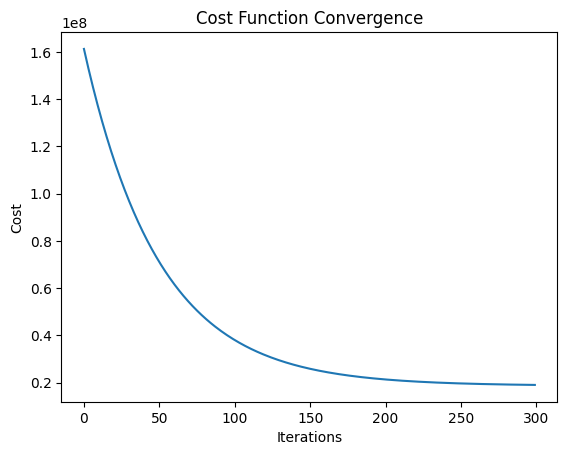

In [25]:
# Cost Convergence Plot

plt.figure()
plt.plot(cost_history)
plt.title("Cost Function Convergence")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.show()


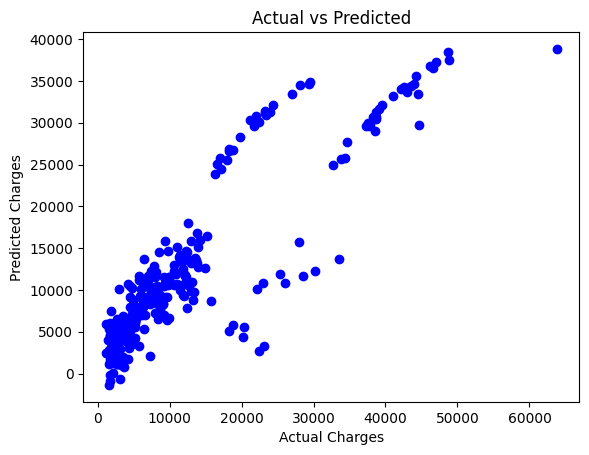

In [26]:
# Actual vs Predicted Plot

plt.scatter(y_test, y_pred, color="blue")

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")

plt.title("Actual vs Predicted")

plt.show()
